# Polynomial Regression

## What is Polynomial Regression?

Polynomial Regression is used when the relationship between the input
feature and target variable is nonlinear or curved.

Instead of using only the original feature `x`, polynomial features such
as `x²`, `x³`, etc. are created.

This allows a Linear Regression model to capture curved relationships.

### Example

Degree 1:
x

Degree 2:
x, x²

Degree 3:
x, x², x³

A very high polynomial degree can cause overfitting, while a degree that
is too low can cause underfitting.

In [26]:
import numpy as np 
import pandas as pd

experience = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])

salary = np.array([
    25, 30, 38, 50, 65,
    85, 110, 140, 175, 215
])

In [27]:
data = pd.DataFrame({"experience": experience,
                    "salary": salary})
data

,experience,salary
0,1,25
1,2,30
2,3,38
3,4,50
4,5,65
5,6,85
6,7,110
7,8,140
8,9,175
9,10,215


In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: xlabel='experience', ylabel='salary'>

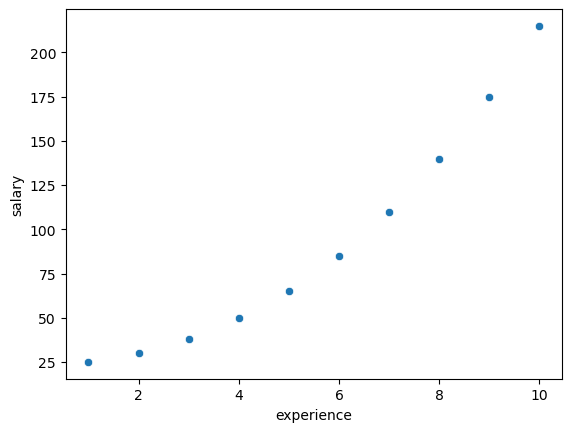

In [29]:
sns.scatterplot(data,
               x="experience",
               y="salary")

In [30]:
X = experience.reshape(-1, 1)
y = salary

In [31]:
X.shape

(10, 1)

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [33]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(8, 1)
(2, 1)
(8,)
(2,)


In [34]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [35]:
y_pred = model.predict(X_train)
y_pred

array([101.43103448,  -2.87931034, 143.15517241,  38.84482759,
       184.87931034,  80.56896552,  59.70689655, 122.29310345])

In [36]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
train_mse = mean_squared_error(y_true=y_train, y_pred=y_pred)
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(y_true=y_train, y_pred=y_pred)
train_r2 = r2_score(y_true=y_train, y_pred=y_pred)

In [37]:
print("train preformance ")
print("Train MSE :", train_mse)
print("Train RMSE:", train_rmse)
print("Train MAE :", train_mae)
print("Train R²  :", train_r2)

train preformance 
Train MSE : 306.6120689655173
Train RMSE: 17.510341771807806
Train MAE : 14.500000000000005
Train R²  : 0.9114349887447957


In [38]:
#test data prediction 
y_test_pred = model.predict(X_test)

test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

In [39]:
print("Test Performance")

print("Test MSE  :", test_mse)
print("Test RMSE :", test_rmse)
print("Test MAE  :", test_mae)
print("Test R²   :", test_r2)

Test Performance
Test MSE  : 132.5175386444708
Test RMSE : 11.511626238046073
Test MAE  : 11.499999999999996
Test R²   : 0.9747885776657368


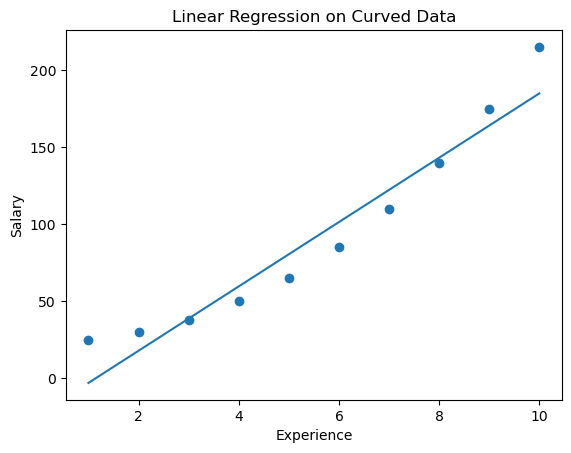

In [40]:
y_line = model.predict(X)

plt.scatter(X, y)
plt.plot(X, y_line)

plt.xlabel("Experience")
plt.ylabel("Salary")
plt.title("Linear Regression on Curved Data")
plt.show()

In [41]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)

In [42]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)

X_poly = poly.fit_transform(X)

X_poly

array([[  1.,   1.],
       [  2.,   4.],
       [  3.,   9.],
       [  4.,  16.],
       [  5.,  25.],
       [  6.,  36.],
       [  7.,  49.],
       [  8.,  64.],
       [  9.,  81.],
       [ 10., 100.]])

In [43]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(
    X_poly,
    y,
    test_size=0.2,
    random_state=42
)

In [44]:
from sklearn.linear_model import LinearRegression
poly_model = LinearRegression()
poly_model.fit(X_train, y_train)

LinearRegression()

In [45]:
poly_pred = poly_model.predict(X_train)
poly_pred

array([ 85.76710006,  26.21085359, 140.9174675 ,  36.60712267,
       213.96947428,  64.90503109,  48.51837196, 111.10457886])

In [46]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
train_mse = mean_squared_error(y_true=y_train, y_pred=poly_pred)
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(y_true=y_train, y_pred=poly_pred)
train_r2 = r2_score(y_true=y_train, y_pred=poly_pred)

In [47]:
print("train preformance ")
print("Train MSE :", train_mse)
print("Train RMSE:", train_rmse)
print("Train MAE :", train_mae)
print("Train R²  :", train_r2)

train preformance 
Train MSE : 1.1653476540418337
Train RMSE: 1.0795126928581404
Train MAE : 1.0000000000000013
Train R²  : 0.9996633888925356


In [48]:
#test data prediction 
poly_test_pred = poly_model.predict(X_test)

test_mse = mean_squared_error(y_test, poly_test_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, poly_test_pred)
test_r2 = r2_score(y_test, poly_test_pred)

In [49]:
print("Test Performance")

print("Test MSE  :", test_mse)
print("Test RMSE :", test_rmse)
print("Test MAE  :", test_mae)
print("Test R²   :", test_r2)

Test Performance
Test MSE  : 0.3645555754034158
Test RMSE : 0.6037843782373107
Test MAE  : 0.5172413793103434
Test R²   : 0.9999306434101491


NameError: name 'linear_model' is not defined

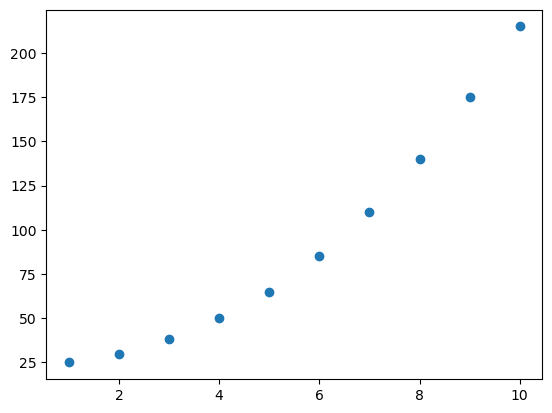

In [50]:
plt.scatter(X, y)
plt.plot(X, linear_model.predict(X))

plt.xlabel("Experience")
plt.ylabel("Salary")
plt.title("Linear Regression")

plt.show()

In [ ]:
plt.scatter(X, y)
plt.plot(X, poly_model.predict(X_poly))

plt.xlabel("Experience")
plt.ylabel("Salary")
plt.title("Polynomial Regression - Degree 2")

plt.show()

In [ ]:
print("Intercept:", poly_model.intercept_)
print("Coefficients:", poly_model.coef_)

## excercise 

In [54]:
from ucimlrepo import fetch_ucirepo

concrete = fetch_ucirepo(id=165)

X = concrete.data.features
y = concrete.data.targets

In [55]:
X.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360


In [56]:
y.head()



,Concrete compressive strength
0,79.99
1,61.89
2,40.27
3,41.05
4,44.30


In [57]:
X.shape


(1030, 8)

In [58]:
y.shape


(1030, 1)

In [59]:
X.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Cement              1030 non-null   float64
 1   Blast Furnace Slag  1030 non-null   float64
 2   Fly Ash             1030 non-null   float64
 3   Water               1030 non-null   float64
 4   Superplasticizer    1030 non-null   float64
 5   Coarse Aggregate    1030 non-null   float64
 6   Fine Aggregate      1030 non-null   float64
 7   Age                 1030 non-null   int64  
dtypes: float64(7), int64(1)
memory usage: 64.5 KB


In [60]:
y.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 1 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Concrete compressive strength  1030 non-null   float64
dtypes: float64(1)
memory usage: 8.2 KB


In [61]:
X.columns

Index(['Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water', 'Superplasticizer',
       'Coarse Aggregate', 'Fine Aggregate', 'Age'],
      dtype='object')

In [62]:
X.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000


In [63]:
y.isnull().sum()

Concrete compressive strength    0
dtype: int64

In [64]:
X.isnull().sum()


Cement                0
Blast Furnace Slag    0
Fly Ash               0
Water                 0
Superplasticizer      0
Coarse Aggregate      0
Fine Aggregate        0
Age                   0
dtype: int64

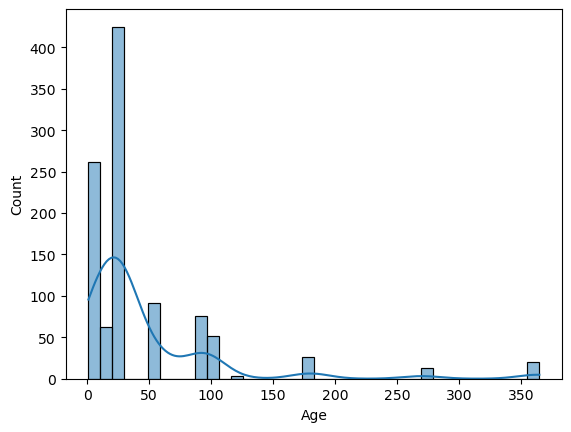

In [65]:
sns.histplot(data=X, x="Age", kde=True)
plt.show()

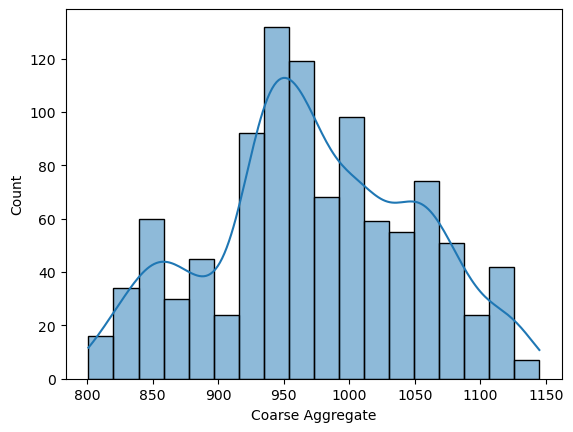

In [66]:
sns.histplot(data=X, x="Coarse Aggregate", kde=True)
plt.show()

In [67]:
X.skew()

Cement                0.509481
Blast Furnace Slag    0.800717
Fly Ash               0.537354
Water                 0.074628
Superplasticizer      0.907203
Coarse Aggregate     -0.040220
Fine Aggregate       -0.253010
Age                   3.269177
dtype: float64

In [68]:
X.skew().sort_values(ascending=False)

Age                   3.269177
Superplasticizer      0.907203
Blast Furnace Slag    0.800717
Fly Ash               0.537354
Cement                0.509481
Water                 0.074628
Coarse Aggregate     -0.040220
Fine Aggregate       -0.253010
dtype: float64

In [69]:
X = concrete.data.features
y = concrete.data.targets

In [73]:
y = y.squeeze()
y

0       79.99
1       61.89
2       40.27
3       41.05
4       44.30
        ...  
1025    44.28
1026    31.18
1027    23.70
1028    32.77
1029    32.40
Name: Concrete compressive strength, Length: 1030, dtype: float64

In [71]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

In [74]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [75]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

LinearRegression()

In [76]:
y_train_pred = linear_model.predict(X_train)
y_test_pred = linear_model.predict(X_test)

In [77]:
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

print("Train Performance")
print("Train MSE  :", train_mse)
print("Train RMSE :", train_rmse)
print("Train MAE  :", train_mae)
print("Train R²   :", train_r2)

Train Performance
Train MSE  : 110.64488699516548
Train RMSE : 10.518787334819802
Train MAE  : 8.330108766506685
Train R²   : 0.610523804764974


In [78]:
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Test Performance")
print("Test MSE  :", test_mse)
print("Test RMSE :", test_rmse)
print("Test MAE  :", test_mae)
print("Test R²   :", test_r2)

Test Performance
Test MSE  : 95.97094009110677
Test RMSE : 9.796475901624358
Test MAE  : 7.745559243921433
Test R²   : 0.6275531792314851


In [80]:
from sklearn.preprocessing import PolynomialFeatures

In [81]:
polymial = PolynomialFeatures(degree=2)

In [91]:
X__poly = polymial.fit_transform(X)
X__poly

array([[1.0000000e+00, 5.4000000e+02, 0.0000000e+00, ..., 4.5697600e+05,
        1.8928000e+04, 7.8400000e+02],
       [1.0000000e+00, 5.4000000e+02, 0.0000000e+00, ..., 4.5697600e+05,
        1.8928000e+04, 7.8400000e+02],
       [1.0000000e+00, 3.3250000e+02, 1.4250000e+02, ..., 3.5283600e+05,
        1.6038000e+05, 7.2900000e+04],
       ...,
       [1.0000000e+00, 1.4850000e+02, 1.3940000e+02, ..., 6.0840000e+05,
        2.1840000e+04, 7.8400000e+02],
       [1.0000000e+00, 1.5910000e+02, 1.8670000e+02, ..., 6.2236321e+05,
        2.2089200e+04, 7.8400000e+02],
       [1.0000000e+00, 2.6090000e+02, 1.0050000e+02, ..., 5.7988225e+05,
        2.1322000e+04, 7.8400000e+02]])

In [92]:
X_train,X_test,y_train,y_test = train_test_split(
    X__poly,
    y,
    test_size=0.2,
    random_state=42
)

In [95]:
from sklearn.linear_model import LinearRegression
polynomial_model = LinearRegression()
polynomial_model.fit(X_train,y_train)

LinearRegression()

In [96]:
ypoly_train_pred = linear_model.predict(X_train)
ypoly_test_pred = linear_model.predict(X_test)

D:\anaconda python\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


ValueError: X has 45 features, but LinearRegression is expecting 8 features as input.

In [97]:
poly__model = LinearRegression()

In [99]:
poly_model.fit(X_train, y_train)

LinearRegression()

In [102]:
ypoly_train_pred = poly_model.predict(X_train)

ypoly_test_pred = poly_model.predict(X_test)

In [105]:
print("Original train:", X_train.shape)
print("Polynomial train:", X_train.shape)

print("Original test:", X_test.shape)
print("Polynomial test:", X_test.shape)

Original train: (824, 45)
Polynomial train: (824, 45)
Original test: (206, 45)
Polynomial test: (206, 45)


In [ ]:
#### new approach 


from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [106]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(
    degree=2,
    include_bias=False
)

In [107]:
X_train_poly = poly.fit_transform(X_train)

X_test_poly = poly.transform(X_test)

In [108]:
print("Original Train :", X_train.shape)
print("Polynomial Train:", X_train_poly.shape)

print("Original Test  :", X_test.shape)
print("Polynomial Test :", X_test_poly.shape)

Original Train : (824, 45)
Polynomial Train: (824, 1080)
Original Test  : (206, 45)
Polynomial Test : (206, 1080)


In [109]:
from sklearn.linear_model import LinearRegression

poly_model = LinearRegression()

In [110]:
poly_model.fit(X_train_poly, y_train)

LinearRegression()

In [111]:
y_train_poly_pred = poly_model.predict(X_train_poly)

y_test_poly_pred = poly_model.predict(X_test_poly)

In [112]:
train_mse = mean_squared_error(y_train, y_train_poly_pred)
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(y_train, y_train_poly_pred)
train_r2 = r2_score(y_train, y_train_poly_pred)

print("Train Performance")
print("Train MSE  :", train_mse)
print("Train RMSE :", train_rmse)
print("Train MAE  :", train_mae)
print("Train R²   :", train_r2)

Train Performance
Train MSE  : 4.861575815976893
Train RMSE : 2.2048981418598212
Train MAE  : 1.3858983951568769
Train R²   : 0.9828869810157966


In [113]:
test_mse = mean_squared_error(y_test, y_test_poly_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, y_test_poly_pred)
test_r2 = r2_score(y_test, y_test_poly_pred)

print("Test Performance")
print("Test MSE  :", test_mse)
print("Test RMSE :", test_rmse)
print("Test MAE  :", test_mae)
print("Test R²   :", test_r2)

Test Performance
Test MSE  : 1807.3335561459337
Test RMSE : 42.51274580812128
Test MAE  : 12.678899431505759
Test R²   : -6.01395272793815
